#### Load the Data

In [13]:
import pandas as pd

# Load the preprocessed datasets
"""
X_train = pd.read_csv("preprocessed_data/X_train.csv")
X_test = pd.read_csv("preprocessed_data/X_test.csv")
y_train = pd.read_csv("preprocessed_data/y_train.csv")
y_test = pd.read_csv("preprocessed_data/y_test.csv")
"""
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the single processed file
data = pd.read_csv("preprocessed_data/processed_mushrooms.csv")

# 2. Separate X and y
X = data.drop('class', axis=1)
y = data['class']

# 3. Perform the split right before training
# Changing random_state will give you a different 'random' split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Recommended to keep the class distribution consistent
)

from sklearn.model_selection import train_test_split

# Split training data into train + validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 6499
Testing set size: 1625


#### Implement the MLP Classifier & Hyper Parameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

# 1. Define the hyperparameter search space
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization term
    'learning_rate_init': [0.001, 0.01]
}

# 2. Initialize the base MLP model
mlp = MLPClassifier(
    max_iter=500,
    activation='relu',
    solver='adam',
    random_state=42
)

# 3. Set up Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1  # Use all available CPU cores
)

# 4. Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

# 5. Retrieve the best model found by Grid Search
best_mlp = grid_search.best_estimator_

mlp = best_mlp

# 6. Print best hyperparameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}


#### Training vs. Validation Error Curves

In [20]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss

mlp_curve = MLPClassifier(
    **grid_search.best_params_,
    activation='relu',
    solver='adam',
    max_iter=1,
    warm_start=True,
    random_state=42
)

In [21]:
train_losses = []
val_losses = []


epochs = 50

import warnings
from sklearn.exceptions import ConvergenceWarning
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for epoch in range(epochs):
        mlp_curve.fit(X_train_sub, y_train_sub)

        # Predict probabilities
        y_train_prob = mlp_curve.predict_proba(X_train_sub)
        y_val_prob = mlp_curve.predict_proba(X_val)

        # Compute loss
        train_loss = log_loss(y_train_sub, y_train_prob)
        val_loss = log_loss(y_val, y_val_prob)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

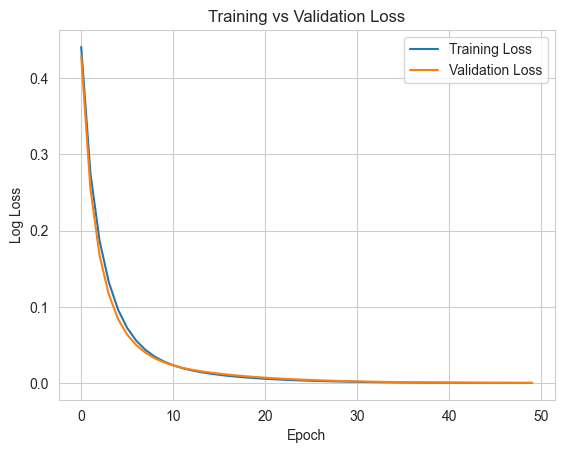

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

#### Evaluate Performance

MLP Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



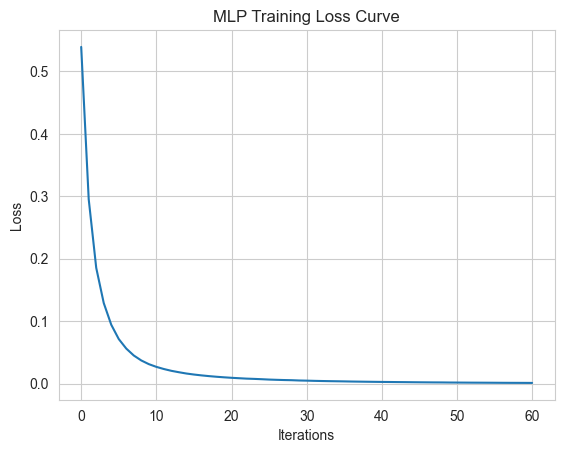

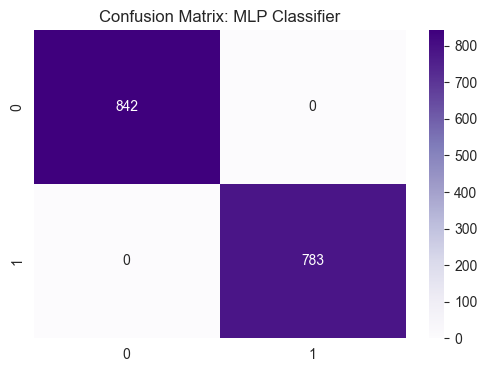

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = mlp.predict(X_test)

# Evaluation metrics
print(f"MLP Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot the Loss Curve
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: MLP Classifier')
plt.show()

K-Fold Cross-Validation

In [24]:
from sklearn.model_selection import cross_validate

# Define the metrics you want to track
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Perform 5-fold cross-validation
results = cross_validate(mlp, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)

# Convert to a DataFrame for a beautiful display in Jupyter
import pandas as pd
results_df = pd.DataFrame(results)
display(results_df)

# Print the mean of the test metrics
print(f"Mean Test Accuracy: {results_df['test_accuracy'].mean():.4f}")
print(f"Mean Test F1-Score: {results_df['test_f1'].mean():.4f}")

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
0,0.314099,0.004997,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0.293000,0.004000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,0.316508,0.005001,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,0.310029,0.005002,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,0.313563,0.004998,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Mean Test Accuracy: 1.0000
Mean Test F1-Score: 1.0000


Permutation Importance check(Robustness)

In [25]:
from sklearn.inspection import permutation_importance
import pandas as pd

# This will take a moment as it re-evaluates the model multiple times
result = permutation_importance(mlp, X_test, y_test, n_repeats=10, random_state=42)

# Organize the results
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(ascending=False, by='importance_mean')

# Print the top 10 features
print(importance_df.head(10))

                     feature  importance_mean  importance_std
32             stalk-shape_t         0.030400        0.002570
34              stalk-root_c         0.021908        0.001297
20               gill-size_n         0.016062        0.002049
64               ring-type_f         0.006338        0.000872
36              stalk-root_r         0.005846        0.000688
19            gill-spacing_w         0.003323        0.000492
73       spore-print-color_u         0.003077        0.000550
33              stalk-root_b         0.003015        0.001009
54  stalk-color-below-ring_n         0.002954        0.000603
80              population_y         0.002277        0.000618
